<a href="https://colab.research.google.com/github/UtharaS123/1D-Signal-Denoising-with-Deep-Learning/blob/main/1D_Signal_Denoising_with_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch numpy scipy matplotlib

In [ ]:
import os
os.makedirs("data/arrays", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [ ]:
"""
generate_signals.py
Synthetic broadband signal generator mimicking proton-acoustic
pulses. Saves train/val/test splits as numpy arrays.
"""

import numpy as np
import os


def gaussian_pulse(t, t0, sigma, amplitude=1.0):
    """Gaussian pulse centred at t0."""
    return amplitude * np.exp(
        -((t - t0) ** 2) / (2 * sigma ** 2))


def generate_sample(length=1024, fs=1e6, snr_db=10.0):
    """
    Generate one (noisy_signal, clean_signal) pair.
    """
    t = np.linspace(0, length / fs, length)

    n_pulses = np.random.randint(1, 4)
    clean = np.zeros(length)
    for _ in range(n_pulses):
        t0        = np.random.uniform(0.2, 0.8) * t[-1]
        sigma     = np.random.uniform(0.02, 0.08) * t[-1]
        amplitude = np.random.uniform(0.5, 1.0)
        clean    += gaussian_pulse(t, t0, sigma, amplitude)

    signal_power = np.mean(clean ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.random.normal(
                       0, np.sqrt(noise_power), length)
    noisy = clean + noise

    return noisy.astype(np.float32), clean.astype(np.float32)


def build_dataset(n_samples=10000, snr_db=10.0,
                  length=1024, seed=42):
    np.random.seed(seed)
    noisy_all = np.zeros((n_samples, 1, length), dtype=np.float32)
    clean_all = np.zeros((n_samples, 1, length), dtype=np.float32)
    for i in range(n_samples):
        noisy, clean       = generate_sample(length=length,
                                             snr_db=snr_db)
        noisy_all[i, 0, :] = noisy
        clean_all[i, 0, :] = clean
    return noisy_all, clean_all


if __name__ == "__main__":
    os.makedirs("data/arrays", exist_ok=True)
    for split, n, seed in [("train",8000,0),
                            ("val",  1000,1),
                            ("test", 1000,2)]:
        noisy, clean = build_dataset(n_samples=n, seed=seed)
        np.save(f"data/arrays/{split}_noisy.npy", noisy)
        np.save(f"data/arrays/{split}_clean.npy", clean)
        print(f"Saved {split}: {n} samples")

# already has __main__ block — just run the cell directly

Saved train: 8000 samples
Saved val: 1000 samples
Saved test: 1000 samples


In [ ]:
noisy_all, clean_all = build_dataset(n_samples=8000, seed=0)
import numpy as np
np.save("data/arrays/train_noisy.npy", noisy_all)
np.save("data/arrays/train_clean.npy", clean_all)
# repeat for val (1000, seed=1) and test (1000, seed=2)

In [ ]:
%%writefile models/unet1d.py
"""
unet1d.py
1D U-Net for signal denoising.
Encoder-decoder with skip connections.
Input/output shape: (B, 1, L)
"""

import torch
import torch.nn as nn


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=9):
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_ch,  out_ch, kernel_size, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet1D(nn.Module):
    """
    Encoder: 4 levels of downsampling (MaxPool x2)
    Decoder: 4 levels of upsampling with skip connections
    """

    def __init__(self, in_channels=1, base_features=32):
        super().__init__()
        f = base_features

        self.enc1 = ConvBlock(in_channels, f)
        self.enc2 = ConvBlock(f,     f * 2)
        self.enc3 = ConvBlock(f * 2, f * 4)
        self.enc4 = ConvBlock(f * 4, f * 8)
        self.pool = nn.MaxPool1d(2)

        self.bottleneck = ConvBlock(f * 8, f * 16)

        self.up4  = nn.ConvTranspose1d(f*16, f*8, 2, stride=2)
        self.dec4 = ConvBlock(f * 16, f * 8)
        self.up3  = nn.ConvTranspose1d(f*8,  f*4, 2, stride=2)
        self.dec3 = ConvBlock(f * 8,  f * 4)
        self.up2  = nn.ConvTranspose1d(f*4,  f*2, 2, stride=2)
        self.dec2 = ConvBlock(f * 4,  f * 2)
        self.up1  = nn.ConvTranspose1d(f*2,  f,   2, stride=2)
        self.dec1 = ConvBlock(f * 2,  f)

        self.out = nn.Conv1d(f, in_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out(d1)

Writing models/unet1d.py


In [ ]:
%%writefile models/autoencoder.py
"""
autoencoder.py
Denoising Autoencoder (DAE) for 1D signal denoising.
Symmetric encoder-decoder; no skip connections.
"""

import torch.nn as nn


class DenoisingAutoencoder(nn.Module):
    def __init__(self, signal_length=1024):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(1,   32,  kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32,  64,  kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64,  128, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 2, stride=2),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 1, 2, stride=2),
            nn.Conv1d(1,   1,  kernel_size=9, padding=4),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

Writing models/autoencoder.py


In [ ]:
%%writefile train.py
"""
train.py
Training loop for signal denoising models.

Usage:
    python train.py --model unet
    python train.py --model autoencoder --epochs 50 --lr 1e-3
"""

import argparse
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from models.unet1d import UNet1D
from models.autoencoder import DenoisingAutoencoder


def load_split(split):
    noisy = torch.from_numpy(np.load(f"data/arrays/{split}_noisy.npy"))
    clean = torch.from_numpy(np.load(f"data/arrays/{split}_clean.npy"))
    return TensorDataset(noisy, clean)


def snr(pred, target):
    signal_power = torch.mean(target ** 2)
    noise_power  = torch.mean((pred - target) ** 2)
    return 10 * torch.log10(signal_power / (noise_power + 1e-10))


def train(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    train_loader = DataLoader(load_split("train"),
                              batch_size=args.batch_size, shuffle=True)
    val_loader   = DataLoader(load_split("val"),
                              batch_size=args.batch_size)

    if args.model == "unet":
        model = UNet1D().to(device)
    else:
        model = DenoisingAutoencoder().to(device)

    optimiser = torch.optim.Adam(model.parameters(), lr=args.lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimiser, patience=5)
    criterion = nn.MSELoss()
    best_val_loss = float("inf")

    for epoch in range(1, args.epochs + 1):
        model.train()
        train_loss = 0.0
        for noisy, clean in train_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            optimiser.zero_grad()
            pred = model(noisy)
            loss = criterion(pred, clean)
            loss.backward()
            optimiser.step()
            train_loss += loss.item()

        model.eval()
        val_loss, val_snr = 0.0, 0.0
        with torch.no_grad():
            for noisy, clean in val_loader:
                noisy, clean = noisy.to(device), clean.to(device)
                pred      = model(noisy)
                val_loss += criterion(pred, clean).item()
                val_snr  += snr(pred, clean).item()

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        val_snr    /= len(val_loader)
        scheduler.step(val_loss)

        print(f"Epoch {epoch:03d} | "
              f"Train: {train_loss:.6f} | "
              f"Val: {val_loss:.6f} | "
              f"Val SNR: {val_snr:.2f} dB")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(),
                       f"checkpoints/{args.model}_best.pt")

    print(f"Done. Best val loss: {best_val_loss:.6f}")


if __name__ == "__main__":
    import os
    os.makedirs("checkpoints", exist_ok=True)
    parser = argparse.ArgumentParser()
    parser.add_argument("--model", default="unet",
                        choices=["unet", "autoencoder"])
    parser.add_argument("--epochs",     type=int,   default=30)
    parser.add_argument("--batch_size", type=int,   default=64)
    parser.add_argument("--lr",         type=float, default=1e-3)
    args = parser.parse_args()
    train(args)

Writing train.py


In [ ]:
!python train.py --model unet --epochs 30 --batch_size 128

Using device: cuda
Epoch 001 | Train: 0.008681 | Val: 0.000456 | Val SNR: 24.75 dB
Epoch 002 | Train: 0.000547 | Val: 0.000429 | Val SNR: 25.03 dB
Epoch 003 | Train: 0.000491 | Val: 0.000285 | Val SNR: 26.79 dB
Epoch 004 | Train: 0.000443 | Val: 0.000247 | Val SNR: 27.42 dB
Epoch 005 | Train: 0.000443 | Val: 0.000263 | Val SNR: 27.13 dB
Epoch 006 | Train: 0.000556 | Val: 0.000384 | Val SNR: 25.49 dB
Epoch 007 | Train: 0.000497 | Val: 0.000228 | Val SNR: 27.77 dB
Epoch 008 | Train: 0.000434 | Val: 0.000801 | Val SNR: 22.32 dB
Epoch 009 | Train: 0.000390 | Val: 0.000338 | Val SNR: 26.05 dB
Epoch 010 | Train: 0.000378 | Val: 0.000186 | Val SNR: 28.65 dB
Epoch 011 | Train: 0.000498 | Val: 0.000181 | Val SNR: 28.76 dB
Epoch 012 | Train: 0.000354 | Val: 0.000161 | Val SNR: 29.29 dB
Epoch 013 | Train: 0.000469 | Val: 0.000268 | Val SNR: 27.06 dB
Epoch 014 | Train: 0.000341 | Val: 0.000237 | Val SNR: 27.59 dB
Epoch 015 | Train: 0.000365 | Val: 0.000198 | Val SNR: 28.38 dB
Epoch 016 | Train: 0.

In [ ]:

!python train.py --model autoencoder --epochs 30 --batch_size 128

Using device: cuda
Epoch 001 | Train: 0.013532 | Val: 0.000573 | Val SNR: 23.75 dB
Epoch 002 | Train: 0.000471 | Val: 0.000369 | Val SNR: 25.66 dB
Epoch 003 | Train: 0.000306 | Val: 0.000288 | Val SNR: 26.75 dB
Epoch 004 | Train: 0.000252 | Val: 0.000224 | Val SNR: 27.84 dB
Epoch 005 | Train: 0.000224 | Val: 0.000319 | Val SNR: 26.31 dB
Epoch 006 | Train: 0.000237 | Val: 0.000235 | Val SNR: 27.64 dB
Epoch 007 | Train: 0.000216 | Val: 0.000330 | Val SNR: 26.15 dB
Epoch 008 | Train: 0.000242 | Val: 0.000206 | Val SNR: 28.21 dB
Epoch 009 | Train: 0.000224 | Val: 0.000194 | Val SNR: 28.47 dB
Epoch 010 | Train: 0.000202 | Val: 0.000183 | Val SNR: 28.73 dB
Epoch 011 | Train: 0.000256 | Val: 0.000492 | Val SNR: 24.42 dB
Epoch 012 | Train: 0.000278 | Val: 0.000188 | Val SNR: 28.60 dB
Epoch 013 | Train: 0.000181 | Val: 0.000175 | Val SNR: 28.91 dB
Epoch 014 | Train: 0.000186 | Val: 0.000249 | Val SNR: 27.38 dB
Epoch 015 | Train: 0.000198 | Val: 0.000175 | Val SNR: 28.91 dB
Epoch 016 | Train: 0.

In [ ]:
%%writefile evaluate.py
"""
evaluate.py
Evaluate all methods (Wiener, DAE, U-Net) on the test set
and produce comparison plots.
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import wiener

from models.unet1d import UNet1D
from models.autoencoder import DenoisingAutoencoder


def compute_snr(pred, target):
    sp  = np.mean(target ** 2)
    np_ = np.mean((pred - target) ** 2)
    return 10 * np.log10(sp / (np_ + 1e-10))


def compute_mse(pred, target):
    return np.mean((pred - target) ** 2)


def load_model(model_class, path, device):
    m = model_class().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m


def run_dl_model(model, noisy_np, device):
    x = torch.from_numpy(noisy_np[:, np.newaxis, :]).to(device)
    with torch.no_grad():
        out = model(x).cpu().numpy()[:, 0, :]
    return out


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available()
                          else "cpu")

    noisy = np.load("data/arrays/test_noisy.npy")[:, 0, :]
    clean = np.load("data/arrays/test_clean.npy")[:, 0, :]

    wiener_out = np.array([wiener(s) for s in noisy])

    unet     = load_model(UNet1D, "checkpoints/unet_best.pt", device)
    dae      = load_model(DenoisingAutoencoder,
                          "checkpoints/autoencoder_best.pt", device)
    unet_out = run_dl_model(unet, noisy, device)
    dae_out  = run_dl_model(dae,  noisy, device)

    results = {
        "Noisy input": (noisy,      "grey"),
        "Wiener":      (wiener_out, "orange"),
        "DAE":         (dae_out,    "green"),
        "1D U-Net":    (unet_out,   "royalblue"),
    }

    print(f"\n{'Method':<18} {'SNR (dB)':>10} {'MSE':>12}")
    print("-" * 42)
    for name, (pred, _) in results.items():
        s = np.mean([compute_snr(pred[i], clean[i])
                     for i in range(len(clean))])
        m = np.mean([compute_mse(pred[i], clean[i])
                     for i in range(len(clean))])
        print(f"{name:<18} {s:>10.2f} {m:>12.6f}")

Overwriting evaluate.py


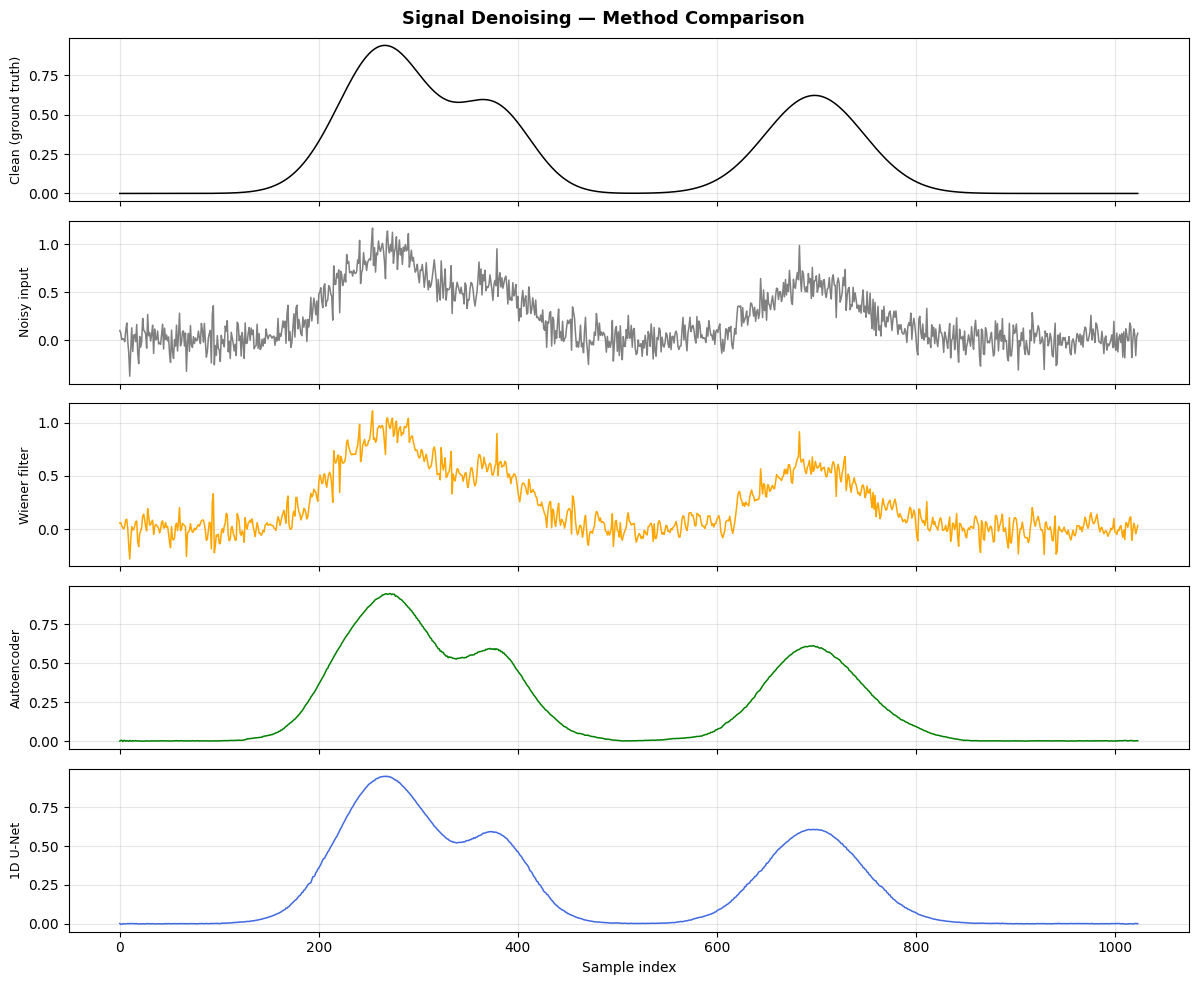

Saved to results/comparison.png


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import wiener
import sys, os
sys.path.insert(0, '/content')
os.makedirs("results", exist_ok=True)

from models.unet1d import UNet1D
from models.autoencoder import DenoisingAutoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

noisy = np.load("data/arrays/test_noisy.npy")[:, 0, :]
clean = np.load("data/arrays/test_clean.npy")[:, 0, :]

def load_model(cls, path):
    m = cls().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m

unet = load_model(UNet1D,               "checkpoints/unet_best.pt")
dae  = load_model(DenoisingAutoencoder, "checkpoints/autoencoder_best.pt")

def predict(model, noisy_np):
    x = torch.from_numpy(noisy_np[:, np.newaxis, :]).to(device)
    with torch.no_grad():
        return model(x).cpu().numpy()[:, 0, :]

wiener_out = np.array([wiener(s) for s in noisy])
unet_out   = predict(unet, noisy)
dae_out    = predict(dae,  noisy)

# plot
idx = 3
t   = np.arange(clean.shape[1])
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, (label, sig, col) in zip(axes, [
    ("Clean (ground truth)", clean[idx],      "black"),
    ("Noisy input",          noisy[idx],      "gray"),
    ("Wiener filter",        wiener_out[idx], "orange"),
    ("Autoencoder",          dae_out[idx],    "green"),
    ("1D U-Net",             unet_out[idx],   "royalblue"),
]):
    ax.plot(t, sig, color=col, lw=1.1)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Sample index")
plt.suptitle("Signal Denoising — Method Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/comparison.png")

In [ ]:
import os
os.makedirs("results", exist_ok=True)

In [ ]:
!python /content/evaluate.py


Method               SNR (dB)          MSE
------------------------------------------
Noisy input             10.01     0.014042
Wiener                  13.21     0.006725
DAE                     30.25     0.000165
1D U-Net                32.77     0.000103


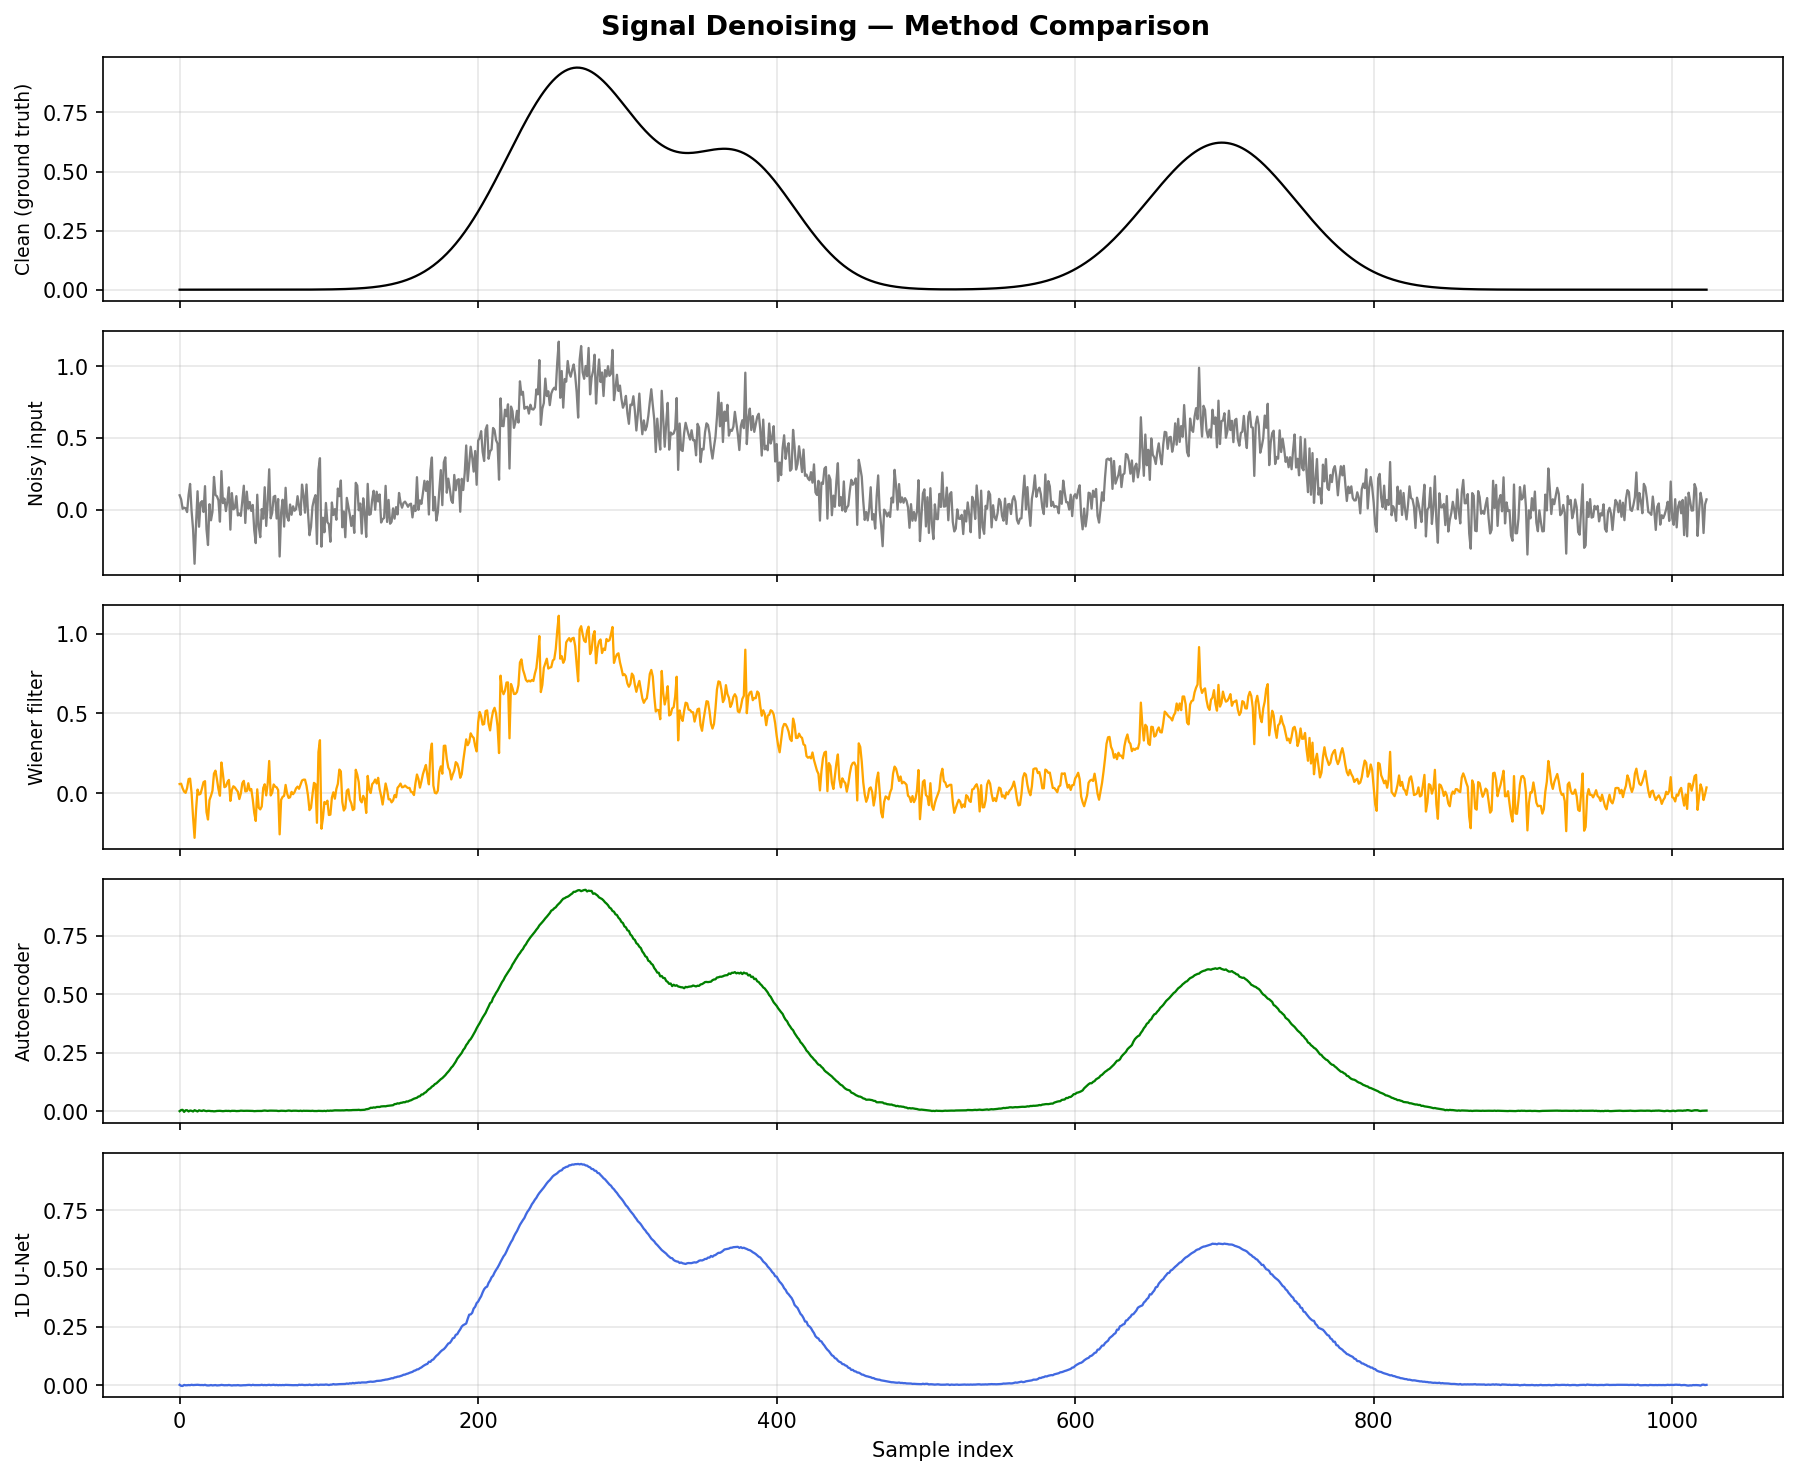

In [ ]:
from IPython.display import Image
Image("results/comparison.png")